# Notebook 13 — Cross-Hospital Commercial Comparison, 73721 (ladder v1.1)

**Purpose.** The public-post hook: same scan (73721, MRI lower-extremity joint, no contrast), several DFW hospitals, one price spread. MCA's commercial allowed (\$906.53) sits against peer commercial rates (Baylor, Methodist, Texas Health Presbyterian, Parkland). The **Step V bar chart is the deliverable** — "≈3.7× Medicare, robust to wage-index sensitivity" (NB11/NB12) is the footnote that defends it, not the headline.

**This notebook needs the DB** (peer commercial rates come from `queries.py`), unlike NB11/NB12. So it is built **DB-independent first**, in the project's standard pattern:
- a **`USE_SYNTHETIC`** switch runs the entire Step R→S→V pipeline now against a seeded synthetic peer frame;
- a **`COLMAP`** + a **`queries.py` pull contract** are defined so the real run is a two-line swap;
- synthetic mode stamps a **`[SYNTHETIC DATA]` watermark** on every chart and printout, so a test render can never be mistaken for the real post.

Carried benchmarks: FFS national \$243.77 (NB11, `confirmed=False`), peer-MA median ~\$233.88 (NB11), MCA commercial \$906.53.

## Step 0 — Setup, mode switch & guard

In [14]:
import sys
from pathlib import Path

def _find_root(start: Path, marker="src") -> Path:
    for p in [start, *start.parents]:
        if (p / marker / "__init__.py").is_file():
            return p
    raise FileNotFoundError(f"Couldn't find 'src/__init__.py' above {start}")

ROOT = _find_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import queries          # <- canonical form now that src is a package
print(f"Path bootstrap OK | ROOT={ROOT}")
print("queries exports:", [n for n in dir(queries) if not n.startswith('_')])

Path bootstrap OK | ROOT=c:\Users\kedha\Documents\dfw-hospital-pricing
queries exports: ['LOB_PATTERNS', 'LOB_PATTERNS_V2', 'PAYER_GROUP_DEFAULTS', 'PAYER_NAME_PATTERNS_V3', 'add_lob', 'add_lob_v2', 'add_lob_v3', 'add_lob_v4', 'classify_plan', 'classify_plan_v2', 'classify_plan_v3', 'classify_plan_v4', 'pd', 'query_procedure_rates_agg', 're']


## Step 1 — Data pull: contract + synthetic frame

**`queries.py` contract** (real mode). Add a function with this signature; it returns one
raw row per (hospital, payer, plan) for the CPT, pre-aggregation:

```python
def commercial_rates_for_cpt(conn, cpt="73721", rate_type="commercial"):
    '''Raw negotiated commercial rows for a CPT across hospitals.
       Returns a DataFrame; raw column names are mapped by COLMAP in NB Step 2.
       Aggregation to one rate per hospital happens in Step 2, not here.'''
```

`COLMAP` maps the raw column names to the canonical ones this notebook uses.

In [15]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

USE_SYNTHETIC = False
MODE_TAG = "[REAL DATA]"

In [16]:
# Canonical columns this notebook works in:  hospital | payer | plan | cpt | rate_type | rate
COLMAP = {
    "hospital_name": "hospital",
    "payer_name":    "payer",
    "plan_name":     "plan",
    "code":          "cpt",
    "rate_type":     "rate_type",
    "negotiated_rate": "rate",
}
CANONICAL = ["hospital", "payer", "plan", "cpt", "rate_type", "rate"]

def _apply_colmap(df, colmap=COLMAP):
    out = df.rename(columns=colmap)
    have = [c for c in CANONICAL if c in out.columns]
    return out[have].copy()

PEER_HOSPITALS = ["MCA", "Baylor", "Methodist", "Texas Health Presbyterian", "Parkland"]

def _synthetic_raw(seed=73721):
    '''Seeded synthetic peer frame — exercises the pipeline only. NOT real rates.'''
    rng = np.random.default_rng(seed)
    centers = {"MCA": 906.53, "Baylor": 770, "Methodist": 835,
               "Texas Health Presbyterian": 690, "Parkland": 615}
    rows = []
    for h in PEER_HOSPITALS:
        if h == "MCA":
            vals = [906.53 - 40, 906.53, 906.53 + 40]
        else:
            vals = np.round(rng.normal(centers[h], 35, size=rng.integers(3, 6)), 2)
        for v in vals:
            rows.append({"hospital_name": h, "payer_name": f"Payer{rng.integers(1,5)}",
                         "plan_name": "PPO", "code": "73721",
                         "rate_type": "commercial", "negotiated_rate": float(v)})
    return pd.DataFrame(rows)

# ── Real-data loader: commercial 73721 rungs across the five DFW hospitals ──
# Emits the SAME canonical long frame as the synthetic path:
#   hospital | payer | plan | cpt | rate_type | rate
# so aggregate() and the recon/spread cell run UNCHANGED.
import duckdb
from src import queries          # src/ is a package (__init__.py present), ROOT on sys.path

# Resolve the data dir robustly: try a few candidates, pick the first that has .duckdb files.
# (ROOT can land in notebooks/ depending on where the kernel's cwd is.)
_candidates = [
    ROOT / "data" / "raw",
    ROOT.parent / "data" / "raw",
    Path.cwd() / "data" / "raw",
    Path.cwd().parent / "data" / "raw",
]
RAW_DIR = next((c for c in _candidates if c.is_dir() and list(c.glob("*.duckdb"))), None)
if RAW_DIR is None:
    raise FileNotFoundError("No data/raw with .duckdb found. Tried:\n  " +
                            "\n  ".join(str(c) for c in _candidates))
print(f"RAW_DIR resolved -> {RAW_DIR}")

CPT_73721 = "73721"
SETTING   = "outpatient"         # query_procedure_rates_agg default

LOB_COL        = "lob"           # add_lob_v4 writes this column
COMMERCIAL_LOB = "commercial"    # bucket string for commercial rows (lowercase)

_HOSPITAL_KEYWORDS = [
    ("baylor", "Baylor"), ("methodist", "Methodist"), ("parkland", "Parkland"),
    ("presby", "Texas Health Presbyterian"), ("plano", "Texas Health Presbyterian"),
    ("thp", "Texas Health Presbyterian"),
    ("mca", "MCA"), ("alliance", "MCA"), ("medical_city", "MCA"),
]
def _resolve_hospital(stem):
    s = stem.lower()
    return next((name for kw, name in _HOSPITAL_KEYWORDS if kw in s), None)

def _load_real_commercial_73721():
    files = sorted(RAW_DIR.glob("*.duckdb"))
    if not files:
        raise FileNotFoundError(f"No .duckdb files found in {RAW_DIR.resolve()}")
    print(f"Discovered {len(files)} duckdb file(s):")
    frames = []
    for fp in files:
        hosp = _resolve_hospital(fp.stem)
        print(f"  {fp.name:44s} -> {hosp if hosp else '‼ UNMAPPED — add a keyword'}")
        if hosp is None:
            continue
        con = duckdb.connect(str(fp), read_only=True)
        try:
            agg = queries.query_procedure_rates_agg(con, code=CPT_73721, setting=SETTING)
        finally:
            con.close()
        if agg.empty:
            print(f"      (no 73721 rows in {hosp})")
            continue
        agg = queries.add_lob_v4(agg)      # adds 'lob' + 'lob_rule'
        agg["hospital"] = hosp
        frames.append(agg)

    if not frames:
        raise RuntimeError("No hospital frames built — check the filename mapping above.")
    allrows = pd.concat(frames, ignore_index=True)

    print(f"\nLOB distribution across all {len(allrows)} raw rows:")
    print(allrows[LOB_COL].value_counts(dropna=False).to_string())

    valid = set(allrows[LOB_COL].dropna().unique())
    if COMMERCIAL_LOB not in valid:
        raise ValueError(f"COMMERCIAL_LOB={COMMERCIAL_LOB!r} not in '{LOB_COL}'. "
                         f"Valid values: {sorted(valid)}")

    comm = allrows[allrows[LOB_COL] == COMMERCIAL_LOB].copy()
    print(f"\nCommercial rows by hospital (before NULL-rate drop):")
    print(comm.groupby("hospital").size().to_string())

    canon = pd.DataFrame({
        "hospital": comm["hospital"], "payer": comm["payer_name"],
        "plan": comm["plan_name"], "cpt": CPT_73721,
        "rate_type": "commercial", "rate": comm["dollar_rate"],
    })

    nan_by_hosp = canon[canon["rate"].isna()].groupby("hospital").size()
    if len(nan_by_hosp):
        print("\n⚠ commercial rows with NULL dollar_rate (likely percent-of-charges, e.g. Parkland):")
        print(nan_by_hosp.to_string())
    return canon.dropna(subset=["rate"]).reset_index(drop=True)

if USE_SYNTHETIC:
    raw = _synthetic_raw()
    df  = _apply_colmap(raw)
else:
    df  = _load_real_commercial_73721()

print(f"\n{MODE_TAG} raw rows: {len(df)} | hospitals: {df['hospital'].nunique()}")
df.head()

RAW_DIR resolved -> c:\Users\kedha\Documents\dfw-hospital-pricing\data\raw
Discovered 5 duckdb file(s):
  baylor_university_medical_center-69947_parsed.duckdb -> Baylor
  medical_city_alliance_hospital-77912_parsed.duckdb -> MCA
  methodist_dallas_medical_center-6000b_parsed.duckdb -> Methodist
  parkland_health-6e88d_parsed.duckdb          -> Parkland
  texas_health_presbyterian_hospital_plano-6ad81_parsed.duckdb -> Texas Health Presbyterian

LOB distribution across all 278 raw rows:
lob
commercial              95
medicare_advantage      73
medicaid_chip           24
tpa_self_funded         16
medicaid_star           15
medicaid_other          12
aca_exchange            12
medicaid_star_plus       8
employer_captive         7
workers_comp             6
unknown                  5
federal_other            3
commercial_specialty     2

Commercial rows by hospital (before NULL-rate drop):
hospital
Baylor                       18
MCA                          24
Methodist                   

,hospital,payer,plan,cpt,rate_type,rate
0,Baylor,Cigna,Local Plus/Market Solutions,73721,commercial,1868.00
1,Baylor,United Healthcare,Commercial Broad,73721,commercial,2620.00
2,Baylor,Blue Cross Blue Shield,Blue Advantage,73721,commercial,722.42
3,Baylor,Curative,Commercial,73721,commercial,2216.04
4,Baylor,Employers Health Network,Commercial,73721,commercial,1875.12


## Step 2 — Normalize & aggregate to one rate per hospital

Filter to commercial / 73721, drop dupes, collapse the per-payer rows to a single
per-hospital figure via `AGG_STAT` (median by default — same choice as the peer-MA rung).

In [17]:
if "require" not in globals():
    def require(*names):
        missing = [n for n in names if n not in globals()]
        if missing:
            raise RuntimeError(f"Prerequisite(s) not defined: {missing}. Run Step 0 / the loader cell first.")
require("df")
AGG_STAT = "median"   # 'median' | 'mean' | 'trimmed' (see Step S for the comparison)

def aggregate(frame, stat="median"):
    f = frame[(frame["rate_type"] == "commercial") & (frame["cpt"] == "73721")].copy()
    f = f.drop_duplicates(subset=["hospital", "payer", "plan", "rate"])
    if stat == "trimmed":
        def _trim(s):
            s = np.sort(s.values)
            return s[1:-1].mean() if len(s) > 2 else s.mean()
        g = f.groupby("hospital")["rate"].apply(_trim)
    else:
        g = f.groupby("hospital")["rate"].agg(stat)
    return g.sort_values(ascending=False)

per_hospital = aggregate(df, AGG_STAT)
print(f"{MODE_TAG} per-hospital commercial ({AGG_STAT}):")
per_hospital

for h in per_hospital.index:
    sub = df[df["hospital"] == h][["payer", "plan", "rate"]].sort_values("rate")
    print(f"\n=== {h}  (n={len(sub)}, median={per_hospital[h]:,.2f}) ===")
    print(sub.to_string(index=False))

[REAL DATA] per-hospital commercial (median):

=== Parkland  (n=11, median=3,937.50) ===
                                 payer                                     plan   rate
CIGNA PARKLAND HEALTH EMPLOYEES [1094] CIGNA PARKLAND HEALTH EMPLOYEES [109400] 2851.5
                          CIGNA [1021]                           CIGNA [102100] 3640.2
               AETNA HEALTHCARE [1004]                           AETNA [100400] 3640.2
          GREAT WEST HEALTHCARE [1037]           GREAT WEST HEALTHCARE [103700] 3640.2
        UNITED HEALTHCARE OF TX [1079]                       UHC - UMR [107903] 3937.5
        UNITED HEALTHCARE OF TX [1079]         UNITED HEALTHCARE OF TX [107900] 3937.5
         BLUE CROSS BLUE SHIELD [1012]      BLUE CROSS BLUE SHIELD PPO [101207] 4368.2
         BLUE CROSS BLUE SHIELD [1012]                BCBS TRADITIONAL [101200] 4368.2
         BLUE CROSS BLUE SHIELD [1012]           BCBS FEDERAL EMPLOYEE [101203] 4368.2
         BLUE CROSS BLUE SHIELD [1012]   

## Step 3 — Carried reference rungs

In [18]:
FFS_NATIONAL   = 243.77    # NB11, corroborated; confirmed=False
PEER_MA_MEDIAN  = 233.88   # NB11, contextual
MCA_COMMERCIAL = 906.53    # carried real anchor

require("per_hospital")
assert "MCA" in per_hospital.index, "MCA missing from the pull — check filter/COLMAP."
print(f"FFS national   : ${FFS_NATIONAL:,.2f}")
print(f"peer-MA median : ${PEER_MA_MEDIAN:,.2f}")
print(f"MCA commercial : ${MCA_COMMERCIAL:,.2f}  (pull says ${per_hospital['MCA']:,.2f})")

FFS national   : $243.77
peer-MA median : $233.88
MCA commercial : $906.53  (pull says $906.53)


## Step R — Reconciliation: the comparison table

In [19]:
require("per_hospital", "FFS_NATIONAL", "MCA_COMMERCIAL")
recon = pd.DataFrame({"commercial_rate": per_hospital})
recon["mult_vs_FFS"]  = recon["commercial_rate"] / FFS_NATIONAL
recon["pct_of_MCA"]   = 100 * recon["commercial_rate"] / per_hospital["MCA"]
recon["rank"]         = recon["commercial_rate"].rank(ascending=False).astype(int)

peer = recon.drop(index="MCA")
spread = {
    "n_hospitals":   len(recon),
    "max":           recon["commercial_rate"].max(),
    "min":           recon["commercial_rate"].min(),
    "median":        recon["commercial_rate"].median(),
    "max_over_min":  recon["commercial_rate"].max() / recon["commercial_rate"].min(),
    "MCA_rank":      int(recon.loc["MCA", "rank"]),
    "MCA_vs_peer_median": per_hospital["MCA"] / peer["commercial_rate"].median(),
}
print(f"{MODE_TAG} spread:")
for k, v in spread.items():
    print(f"  {k:22s}: {v:,.2f}" if isinstance(v, float) else f"  {k:22s}: {v}")
print()
recon

[REAL DATA] spread:
  n_hospitals           : 5
  max                   : 3,937.50
  min                   : 906.53
  median                : 1,518.00
  max_over_min          : 4.34
  MCA_rank              : 5
  MCA_vs_peer_median    : 0.52



,commercial_rate,mult_vs_FFS,pct_of_MCA,rank
hospital,,,,
Parkland,3937.50,16.152521,434.348560,1
Baylor,1944.56,7.977028,214.505863,2
Methodist,1518.00,6.227181,167.451711,3
Texas Health Presbyterian,1262.69,5.179842,139.288275,4
MCA,906.53,3.718792,100.000000,5


## Step S — Robustness: aggregation statistic & chargemaster-leak scan

(1) Does the ranking/spread survive median vs mean vs trimmed?  (2) Does any hospital's
rate look like a chargemaster figure leaking into the commercial bucket — the same failure
mode as NB11's Parkland \$1,274 MA outlier? Flag anything above `LEAK_MULT x` FFS.

In [20]:
require("df", "FFS_NATIONAL")
sens = pd.DataFrame({s: aggregate(df, s) for s in ["median", "mean", "trimmed"]})
sens["spread_max_min"] = np.nan
sens.loc[sens.index[0], "spread_max_min"] = (
    sens[["median", "mean", "trimmed"]].max().max() /
    sens[["median", "mean", "trimmed"]].min().min())
print(f"{MODE_TAG} per-hospital under each statistic:")
print(sens[["median", "mean", "trimmed"]])

LEAK_MULT = 6.0
flags = per_hospital[per_hospital > LEAK_MULT * FFS_NATIONAL]
print(f"\nChargemaster-leak scan (> {LEAK_MULT:.0f}x FFS = > ${LEAK_MULT*FFS_NATIONAL:,.0f}):",
      "none" if flags.empty else f"\n{flags}")
print("  (Parkland warrants the same scrutiny it got in NB11 before trusting its bar.)")

[REAL DATA] per-hospital under each statistic:
                            median         mean      trimmed
hospital                                                    
Baylor                     1944.56  1903.341111  1932.357500
MCA                         906.53   769.158667   763.826923
Methodist                  1518.00  1274.444348  1222.150000
Parkland                   3937.50  3953.463636  4029.822222
Texas Health Presbyterian  1262.69  1289.772500  1267.603000

Chargemaster-leak scan (> 6x FFS = > $1,463): 
hospital
Parkland     3937.50
Baylor       1944.56
Methodist    1518.00
Name: rate, dtype: float64
  (Parkland warrants the same scrutiny it got in NB11 before trusting its bar.)


## Step V — The bar chart (post artifact)

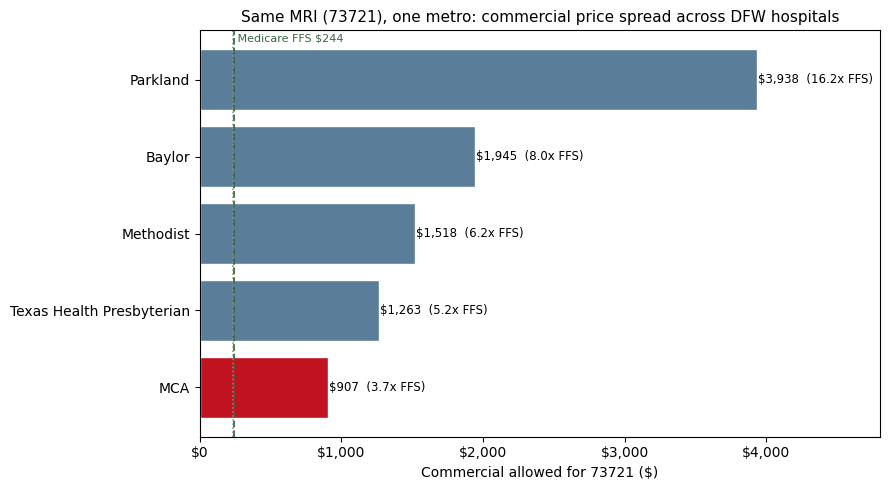

In [21]:
require("per_hospital", "FFS_NATIONAL", "PEER_MA_MEDIAN")
order = per_hospital.sort_values()
colors = ["#c1121f" if h == "MCA" else "#5a7d9a" for h in order.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(order.index, order.values, color=colors, edgecolor="white")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.set_xlabel("Commercial allowed for 73721 ($)")

# reference lines: Medicare FFS and peer-MA median
ax.axvline(FFS_NATIONAL, color="#386641", ls="--", lw=1.3)
ax.text(FFS_NATIONAL, len(order)-0.4, f" Medicare FFS ${FFS_NATIONAL:,.0f}",
        color="#386641", fontsize=8, va="top")
ax.axvline(PEER_MA_MEDIAN, color="#8a8a8a", ls=":", lw=1.1)

for b, v in zip(bars, order.values):
    ax.text(v + 8, b.get_y() + b.get_height()/2,
            f"${v:,.0f}  ({v/FFS_NATIONAL:.1f}x FFS)", va="center", fontsize=8.5)

ax.set_xlim(0, order.values.max() * 1.22)
title = "Same MRI (73721), one metro: commercial price spread across DFW hospitals"
MODE_TAG = ""
ax.set_title(title, fontsize=11)
plt.tight_layout()
plt.show()

## Findings

- **The hook is the spread, not the multiple.** One CPT, hospitals in the same metro, a max/min commercial ratio of `max_over_min` (Step R). The Medicare-FFS reference line underneath turns "expensive" into "≈N× what Medicare pays for the identical scan."
- **MCA's position is the story anchor.** Its rank and its ratio-to-peer-median (Step R) say whether MCA is the outlier or merely typical of a broadly inflated market — a different post either way.
- **The robustness check pre-empts the obvious pushback.** Median/mean/trimmed agreement (Step S) answers "you cherry-picked the statistic," and the chargemaster-leak scan answers "one number is garbage" before anyone raises it.
- **Caveats to carry into the post.** (1) Synthetic vs real — never post a `[SYNTHETIC DATA]` render. (2) Parkland gets the NB11 outlier scrutiny before its bar is trusted. (3) Match the commercial-rate vintage to the FFS/MA vintage (CY2026) or label the mismatch. (4) FFS line is `confirmed=False` until the literal Addendum B check.

## Integrity self-test

In [22]:
# structural / mode-independent
assert set(["hospital","cpt","rate_type","rate"]).issubset(df.columns)
assert (per_hospital > 0).all() and np.isfinite(per_hospital.values).all()
assert "MCA" in per_hospital.index
assert len(per_hospital) >= 2 and recon["commercial_rate"].max() > recon["commercial_rate"].min()

# multiple math is internally consistent
assert np.allclose(recon["mult_vs_FFS"], recon["commercial_rate"] / FFS_NATIONAL)

# MCA carried anchor reproduces (synthetic frame built so MCA median == 906.53)
assert np.isclose(per_hospital["MCA"], MCA_COMMERCIAL, atol=0.01)
assert np.isclose(MCA_COMMERCIAL / FFS_NATIONAL, 3.719, atol=0.01)

# synthetic frame carries the intended hospitals
if USE_SYNTHETIC:
    assert set(PEER_HOSPITALS).issubset(set(per_hospital.index))

print("ALL INTEGRITY CHECKS PASSED" + (f"  {MODE_TAG}" if MODE_TAG else ""))

ALL INTEGRITY CHECKS PASSED
